# Preprocessing Experiment: Strategy B CLAHE vs False Angry Rate

This notebook tests whether adaptive CLAHE (Strategy B) reduces false Angry predictions and improves fairness across skin-tone groups.

## 1. Setup

In [1]:
import os
from pathlib import Path
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(PROJECT_ROOT)

# Coverage audit across manual labels, annotations, and landmark features
manual_path = Path("data/1408-1010-intermediate/manual_labels_export.csv")
ann_path = Path("data/1408-1010-intermediate/annotations.csv")
landmark_path = Path("data/1408-1010-intermediate/landmark_features.csv")

manual = pd.read_csv(manual_path)
ann = pd.read_csv(ann_path)
landmark = pd.read_csv(landmark_path)

manual_set = set(manual["filename"].dropna().astype(str).str.strip().unique())
ann_set = set(ann["filename"].dropna().astype(str).str.strip().unique())
landmark_set = set(landmark["face_filename"].dropna().astype(str).str.strip().unique())

both_manual_ann = manual_set & ann_set
both_manual_landmark = manual_set & landmark_set
all_three = manual_set & ann_set & landmark_set

print("Unique filename counts")
print("manual_labels_export.csv:", len(manual_set))
print("annotations.csv:", len(ann_set))
print("landmark_features.csv:", len(landmark_set))

print("\nOverlap counts")
print("manual_labels ∩ annotations:", len(both_manual_ann))
print("manual_labels ∩ landmark_features:", len(both_manual_landmark))
print("manual_labels ∩ annotations ∩ landmark_features:", len(all_three))

print("\nPreprocessing experiment working set")
print("manual_labels ∩ annotations:", len(both_manual_ann))

Unique filename counts
manual_labels_export.csv: 227
annotations.csv: 227
landmark_features.csv: 85

Overlap counts
manual_labels ∩ annotations: 227
manual_labels ∩ landmark_features: 85
manual_labels ∩ annotations ∩ landmark_features: 85

Preprocessing experiment working set
manual_labels ∩ annotations: 227


In [2]:
import os
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from hsemotion_onnx.facial_emotions import HSEmotionRecognizer

if "__file__" in globals():
    PROJECT_ROOT = Path(__file__).resolve().parent.parent
else:
    cwd = Path.cwd().resolve()
    PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

os.chdir(PROJECT_ROOT)
print("Working directory set to:", Path.cwd())

plt.style.use("default")
ASSET_DIR = Path("reports/assets")
ASSET_DIR.mkdir(parents=True, exist_ok=True)

MANUAL_PATH = Path("data/1408-1010-intermediate/manual_labels_export.csv")
FACES_DIR = Path("data/1408-1010-intermediate/faces")
ORIG_ANN_PATH = Path("data/1408-1010-intermediate/annotations.csv")
CLAHE_OUT_PATH = Path("data/1408-1010-intermediate/clahe_predictions.csv")
SUMMARY_OUT_PATH = Path("reports/preprocessing_experiment_summary.csv")

manual_df = pd.read_csv(MANUAL_PATH)
orig_ann_df = pd.read_csv(ORIG_ANN_PATH)
setup_merge = manual_df.merge(orig_ann_df, on="filename", how="left", suffixes=("_manual", "_orig"))
print("manual_df shape:", manual_df.shape)
print("orig_ann_df shape:", orig_ann_df.shape)
print("setup_merge shape:", setup_merge.shape)
display(setup_merge.head())

Working directory set to: /Users/MAC/Projects/FER-Dataset
manual_df shape: (227, 6)
orig_ann_df shape: (227, 3)
setup_merge shape: (227, 8)


,filename,gt_label,model_label,confidence_manual,notes,labeled_at,label,confidence_orig
0,frame_000008_face01.jpg,Neutral,Fear,0.364011,NaN,2026-08-14T17:30:50.335Z,Fear,0.364011
1,frame_000008_face02.jpg,Neutral,Fear,0.494669,NaN,2026-08-14T17:31:44.953Z,Fear,0.494669
2,frame_000008_face03.jpg,Neutral,Fear,0.384785,NaN,2026-08-14T17:31:47.980Z,Fear,0.384785
3,frame_000009_face01.jpg,Ambiguous,Anger,0.410660,NaN,2026-08-14T17:32:14.629Z,Anger,0.410660
4,frame_000009_face02.jpg,Neutral,Fear,0.339235,NaN,2026-08-14T17:32:21.113Z,Fear,0.339235


## 2. Strategy B CLAHE Function

In [3]:
def compute_l_weighted(img_bgr):
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    L = lab[:, :, 0].astype(np.float32)
    h, w = L.shape
    cy, cx = h // 2, w // 2
    half = max(int(min(h, w) * 0.4 / 2), 1)
    L_center = float(np.mean(L[cy-half:cy+half, cx-half:cx+half]))
    return 0.2 * float(np.mean(L)) + 0.3 * float(np.median(L)) + 0.5 * L_center

def apply_strategy_b_clahe(img_bgr, clip_min=1.5, clip_max=3.5, l_min=60, l_max=220):
    l_w = compute_l_weighted(img_bgr)
    clip = clip_max - (clip_max - clip_min) * (l_w - l_min) / (l_max - l_min)
    clip = float(np.clip(clip, clip_min, clip_max))
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR), l_w, clip

def softmax(logits):
    x = np.asarray(logits, dtype=np.float32)
    x = x - np.max(x)
    ex = np.exp(x)
    return ex / np.sum(ex)

def skin_tone_from_lw(l_w):
    if l_w < 100:
        return "Dark"
    if l_w < 150:
        return "Medium-Dark"
    if l_w < 190:
        return "Medium-Light"
    return "Light"

label_map = {"Anger": "Angry", "Happiness": "Happy", "Sadness": "Sad"}

def normalize_label(v):
    if pd.isna(v):
        return np.nan
    s = str(v).strip()
    return label_map.get(s, s)

## 3. Run CLAHE + Re-classify

In [4]:
fer = HSEmotionRecognizer(model_name='enet_b0_8_best_vgaf')
orig_ann = pd.read_csv(ORIG_ANN_PATH).copy()
orig_ann["label"] = orig_ann["label"].map(normalize_label)
orig_ann["confidence"] = pd.to_numeric(orig_ann["confidence"], errors="coerce")
orig_lookup = orig_ann.set_index("filename")[["label", "confidence"]].to_dict(orient="index")

records = []
for fp in tqdm(sorted(FACES_DIR.glob("*.jpg")), desc="CLAHE re-classify"):
    img_bgr = cv2.imread(str(fp))
    if img_bgr is None:
        continue
    clahe_img, l_weighted, clip_used = apply_strategy_b_clahe(img_bgr)
    label, scores = fer.predict_emotions(clahe_img, logits=True)
    clahe_label = normalize_label(label)
    clahe_conf = float(np.max(softmax(scores)))

    orig = orig_lookup.get(fp.name, {})
    original_label = normalize_label(orig.get("label", np.nan))
    original_confidence = pd.to_numeric(orig.get("confidence", np.nan), errors="coerce")

    records.append({
        "filename": fp.name,
        "original_label": original_label,
        "original_confidence": float(original_confidence) if pd.notna(original_confidence) else np.nan,
        "clahe_label": clahe_label,
        "clahe_confidence": clahe_conf,
        "l_weighted": float(l_weighted),
        "clip_limit_used": float(clip_used),
        "label_changed": bool(pd.notna(original_label) and original_label != clahe_label),
        "skin_tone": skin_tone_from_lw(float(l_weighted)),
    })

clahe_pred_df = pd.DataFrame(records)
clahe_pred_df.to_csv(CLAHE_OUT_PATH, index=False)
print("Saved:", CLAHE_OUT_PATH)
display(clahe_pred_df.head())


CLAHE re-classify:   0%|          | 0/227 [00:00<?, ?it/s]


CLAHE re-classify:   0%|          | 1/227 [00:00<00:25,  8.75it/s]


CLAHE re-classify:   5%|▍         | 11/227 [00:00<00:03, 57.09it/s]


CLAHE re-classify:   9%|▉         | 21/227 [00:00<00:02, 74.01it/s]


CLAHE re-classify:  14%|█▎        | 31/227 [00:00<00:02, 82.71it/s]

...


CLAHE re-classify:  93%|█████████▎| 210/227 [00:02<00:00, 91.33it/s]


CLAHE re-classify:  97%|█████████▋| 220/227 [00:02<00:00, 92.64it/s]


CLAHE re-classify: 100%|██████████| 227/227 [00:02<00:00, 88.41it/s]

Saved: data/1408-1010-intermediate/clahe_predictions.csv


,filename,original_label,original_confidence,clahe_label,clahe_confidence,l_weighted,clip_limit_used,label_changed,skin_tone
0,frame_000008_face01.jpg,Fear,0.364011,Fear,0.399876,20.162622,3.500000,False,Dark
1,frame_000008_face02.jpg,Fear,0.494669,Fear,0.339152,42.803422,3.500000,False,Dark
2,frame_000008_face03.jpg,Fear,0.384785,Fear,0.384628,17.529336,3.500000,False,Dark
3,frame_000009_face01.jpg,Angry,0.410660,Neutral,0.618133,43.753909,3.500000,True,Dark
4,frame_000009_face02.jpg,Fear,0.339235,Sad,0.203460,73.157290,3.335534,True,Dark


## 4. Label Change Analysis

Changed labels: 58/227
Originally Angry changed away: 7/41


clahe_label,Angry,Fear,Happy,Neutral,Sad,Surprise
original_label,,,,,,
Angry,34,2,0,4,1,0
Fear,2,55,1,20,4,1
Happy,1,0,3,1,0,0
Neutral,3,11,2,70,1,1
Sad,1,0,0,0,6,0
Surprise,0,2,0,0,0,1


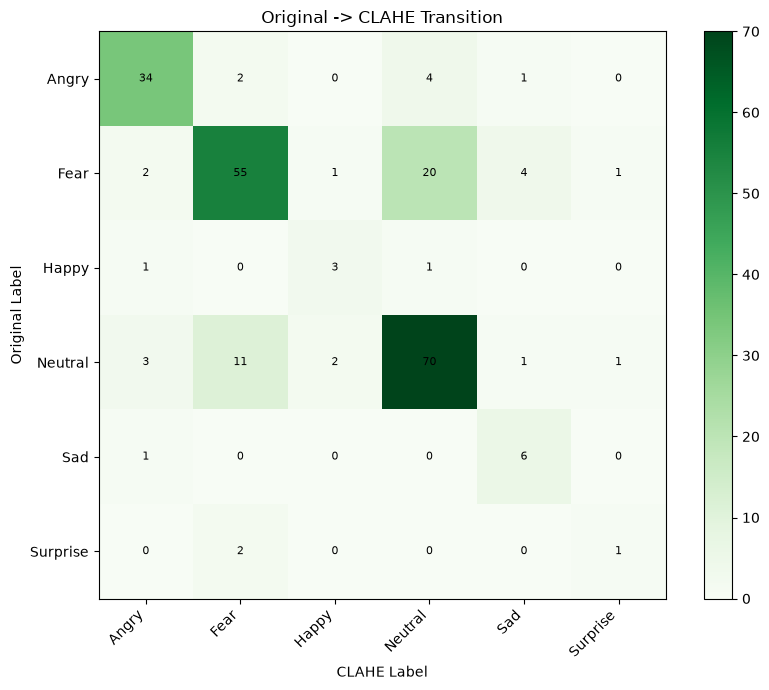

In [5]:
changed_n = int(clahe_pred_df["label_changed"].fillna(False).sum())
total_n = len(clahe_pred_df)
orig_angry = clahe_pred_df[clahe_pred_df["original_label"] == "Angry"]
angry_to_other_n = int((orig_angry["clahe_label"] != "Angry").sum())
print(f"Changed labels: {changed_n}/{total_n}")
print(f"Originally Angry changed away: {angry_to_other_n}/{len(orig_angry)}" if len(orig_angry) else "No original Angry rows")
transition = pd.crosstab(clahe_pred_df["original_label"], clahe_pred_df["clahe_label"], dropna=False)
display(transition)

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(transition.values, cmap="Greens")
ax.set_xticks(range(len(transition.columns)))
ax.set_xticklabels(transition.columns, rotation=45, ha="right")
ax.set_yticks(range(len(transition.index)))
ax.set_yticklabels(transition.index)
ax.set_xlabel("CLAHE Label")
ax.set_ylabel("Original Label")
ax.set_title("Original -> CLAHE Transition")
for i in range(transition.shape[0]):
    for j in range(transition.shape[1]):
        ax.text(j, i, str(int(transition.iat[i, j])), ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(ASSET_DIR / "prep_label_transition_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

## 5. False Angry Rate Comparison

False Angry rate BEFORE: 0.1762114537444934
False Angry rate AFTER : 0.18061674008810572


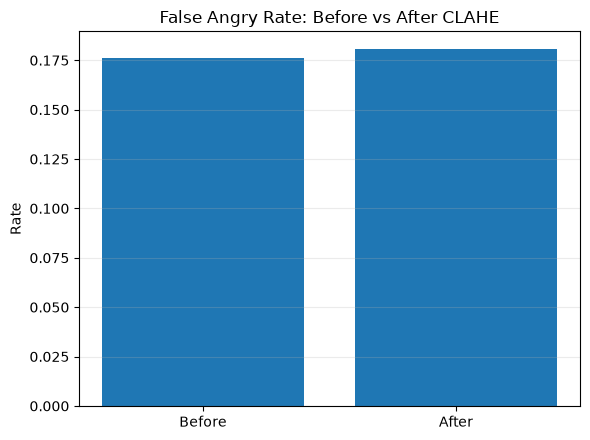

,skin_tone,before_false_angry,after_false_angry
0,Dark,0.106918,0.113208
1,Medium-Dark,0.353846,0.353846
2,Medium-Light,0.000000,0.000000


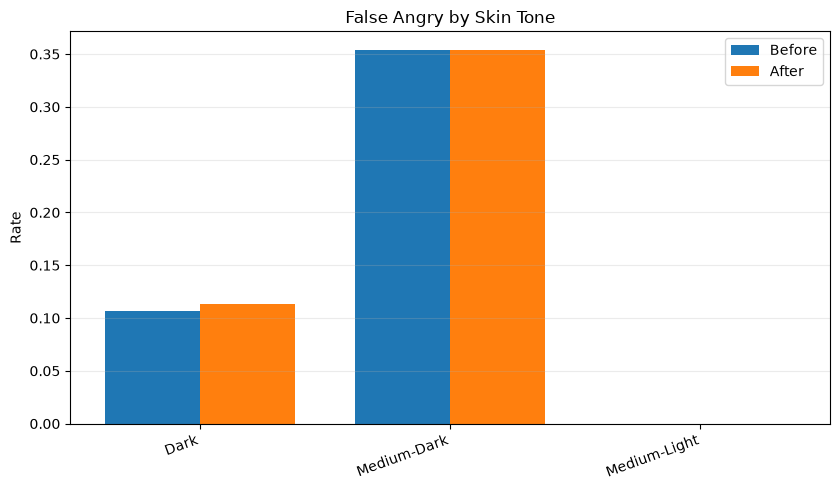

In [6]:
manual = pd.read_csv(MANUAL_PATH).copy()
manual["gt_label"] = manual["gt_label"].map(normalize_label)
eval_df = manual[["filename", "gt_label"]].merge(clahe_pred_df, on="filename", how="inner")
eval_df = eval_df.dropna(subset=["gt_label", "original_label", "clahe_label"])

before_false_angry = ((eval_df["original_label"] == "Angry") & (eval_df["gt_label"] != "Angry")).mean()
after_false_angry = ((eval_df["clahe_label"] == "Angry") & (eval_df["gt_label"] != "Angry")).mean()
print("False Angry rate BEFORE:", before_false_angry)
print("False Angry rate AFTER :", after_false_angry)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(["Before", "After"], [before_false_angry, after_false_angry])
ax.set_title("False Angry Rate: Before vs After CLAHE")
ax.set_ylabel("Rate")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(ASSET_DIR / "prep_false_angry_before_after.png", dpi=200, bbox_inches="tight")
plt.show()

skin_breakdown = eval_df.groupby("skin_tone").apply(lambda g: pd.Series({
    "before_false_angry": ((g["original_label"] == "Angry") & (g["gt_label"] != "Angry")).mean(),
    "after_false_angry": ((g["clahe_label"] == "Angry") & (g["gt_label"] != "Angry")).mean(),
})).reset_index()
display(skin_breakdown)

x = np.arange(len(skin_breakdown)); w = 0.38
fig, ax = plt.subplots(figsize=(8.5, 5))
if len(skin_breakdown):
    ax.bar(x - w/2, skin_breakdown["before_false_angry"], width=w, label="Before")
    ax.bar(x + w/2, skin_breakdown["after_false_angry"], width=w, label="After")
    ax.set_xticks(x)
    ax.set_xticklabels(skin_breakdown["skin_tone"], rotation=20, ha="right")
ax.set_title("False Angry by Skin Tone")
ax.set_ylabel("Rate")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(ASSET_DIR / "prep_false_angry_by_skin_tone.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. Accuracy Comparison

Overall accuracy BEFORE: 0.22466960352422907
Overall accuracy AFTER : 0.19823788546255505


,skin_tone,before_acc,after_acc
0,Dark,0.276730,0.251572
1,Medium-Dark,0.107692,0.076923
2,Medium-Light,0.000000,0.000000


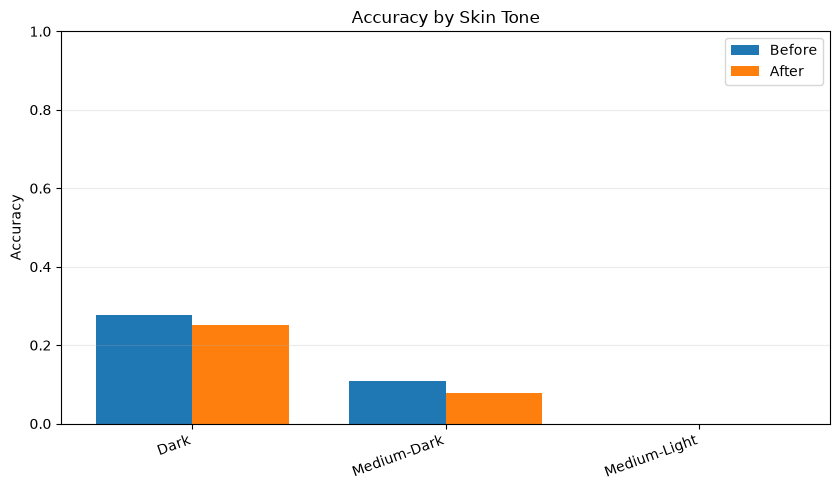

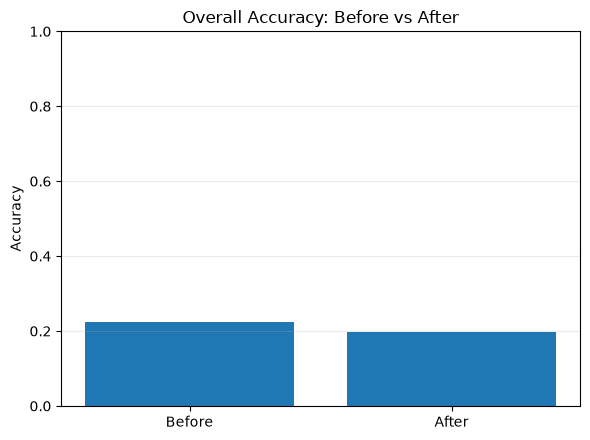

In [7]:
before_acc = (eval_df["gt_label"] == eval_df["original_label"]).mean()
after_acc = (eval_df["gt_label"] == eval_df["clahe_label"]).mean()
print("Overall accuracy BEFORE:", before_acc)
print("Overall accuracy AFTER :", after_acc)

per_skin_acc = eval_df.groupby("skin_tone").apply(lambda g: pd.Series({
    "before_acc": (g["gt_label"] == g["original_label"]).mean(),
    "after_acc": (g["gt_label"] == g["clahe_label"]).mean(),
})).reset_index()
display(per_skin_acc)

x = np.arange(len(per_skin_acc)); w = 0.38
fig, ax = plt.subplots(figsize=(8.5, 5))
if len(per_skin_acc):
    ax.bar(x - w/2, per_skin_acc["before_acc"], width=w, label="Before")
    ax.bar(x + w/2, per_skin_acc["after_acc"], width=w, label="After")
    ax.set_xticks(x)
    ax.set_xticklabels(per_skin_acc["skin_tone"], rotation=20, ha="right")
ax.set_title("Accuracy by Skin Tone")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(ASSET_DIR / "prep_accuracy_by_skin_tone_before_after.png", dpi=200, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(["Before", "After"], [before_acc, after_acc])
ax.set_title("Overall Accuracy: Before vs After")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(ASSET_DIR / "prep_accuracy_overall_before_after.png", dpi=200, bbox_inches="tight")
plt.show()

## 7. Confidence Shift

Confidence down rate: 0.4
Label changed rate: 0.15


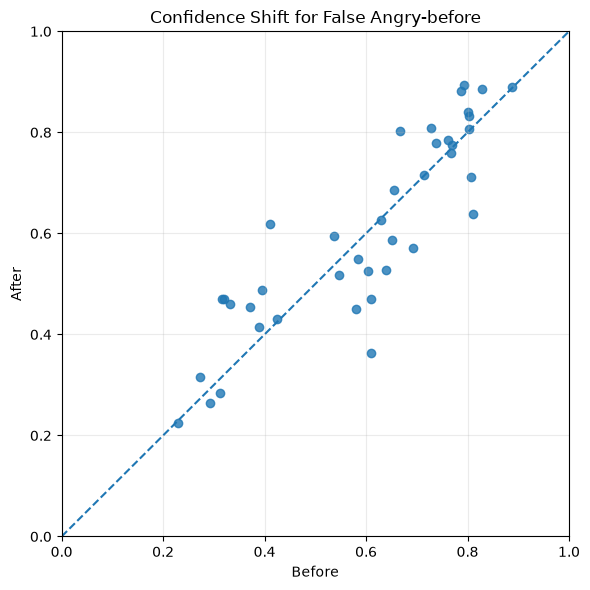

In [8]:
false_angry_before_df = eval_df[(eval_df["original_label"] == "Angry") & (eval_df["gt_label"] != "Angry")].copy()
if len(false_angry_before_df):
    conf_down_rate = (false_angry_before_df["clahe_confidence"] < false_angry_before_df["original_confidence"]).mean()
    label_changed_rate = (false_angry_before_df["clahe_label"] != false_angry_before_df["original_label"]).mean()
else:
    conf_down_rate = np.nan
    label_changed_rate = np.nan
print("Confidence down rate:", conf_down_rate)
print("Label changed rate:", label_changed_rate)

fig, ax = plt.subplots(figsize=(6, 6))
if len(false_angry_before_df):
    ax.scatter(false_angry_before_df["original_confidence"], false_angry_before_df["clahe_confidence"], alpha=0.8)
ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel("Before")
ax.set_ylabel("After")
ax.set_title("Confidence Shift for False Angry-before")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(ASSET_DIR / "prep_confidence_shift_false_angry_before.png", dpi=200, bbox_inches="tight")
plt.show()

## 8. Visual Examples

,filename,gt_label,original_label,original_confidence,clahe_label,clahe_confidence,clip_limit_used
3,frame_000009_face01.jpg,Ambiguous,Angry,0.410660,Neutral,0.618133,3.500000
43,frame_000014_face06.jpg,Neutral,Angry,0.311633,Neutral,0.283480,3.065007
49,frame_000015_face05.jpg,Ambiguous,Angry,0.230052,Neutral,0.224421,3.322042
152,frame_000047_face02.jpg,Neutral,Angry,0.320499,Fear,0.469354,2.969132
155,frame_000048_face02.jpg,Angry,Angry,0.419401,Fear,0.481880,2.881387


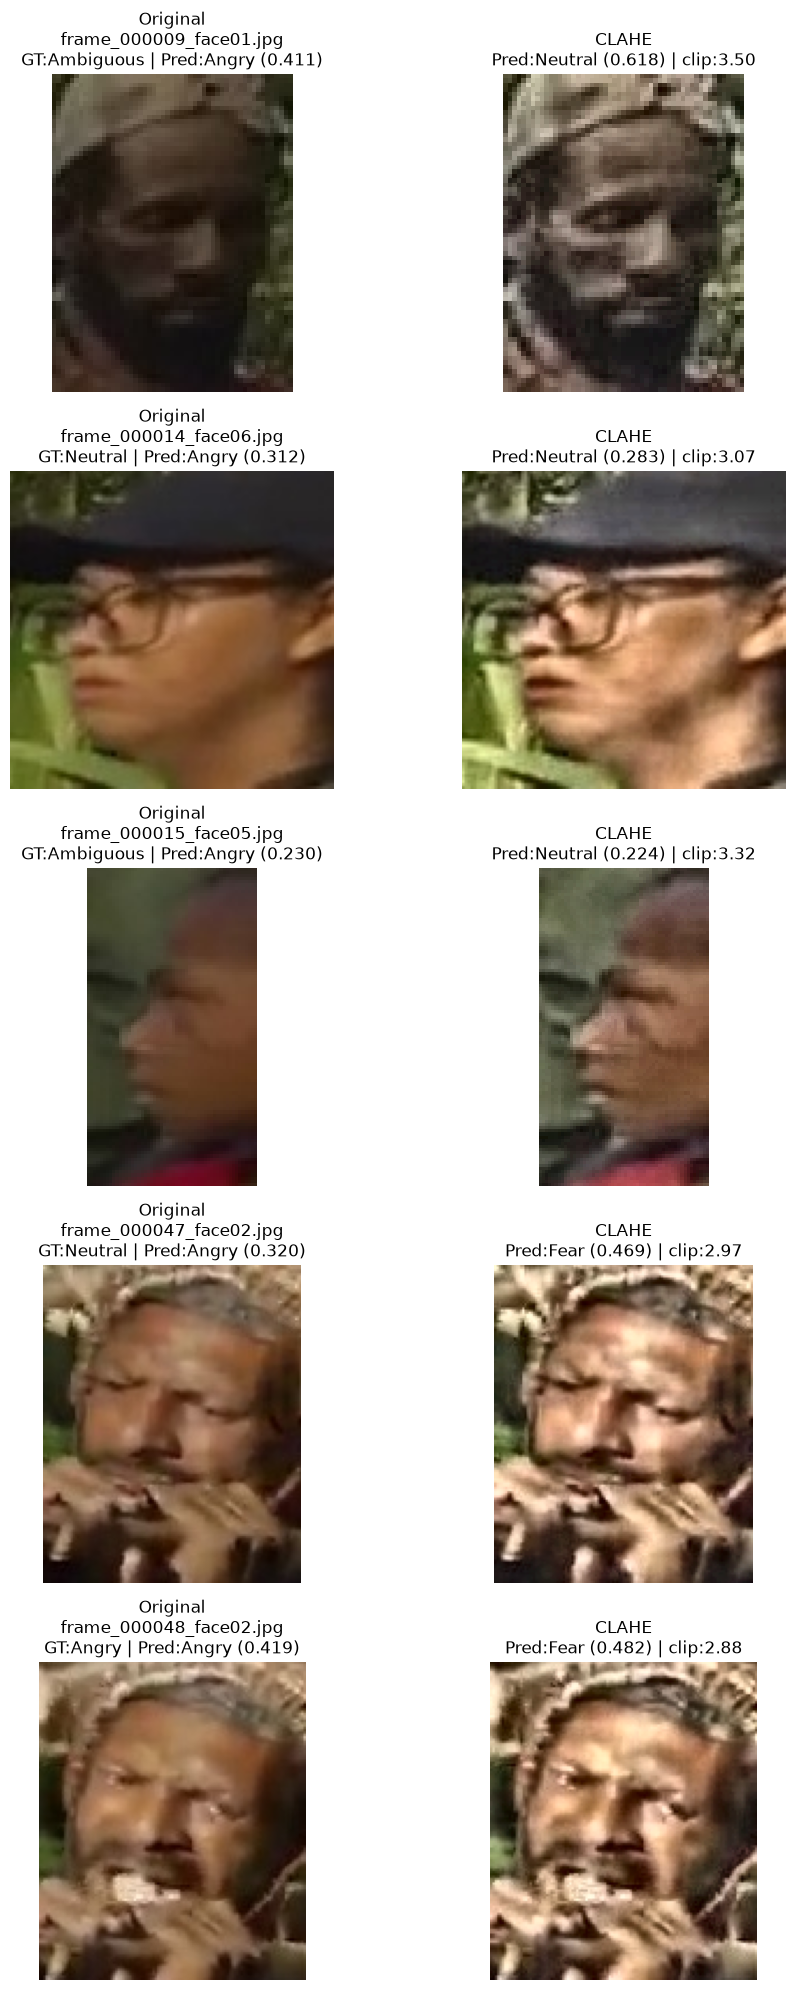

In [9]:
examples = eval_df[(eval_df["original_label"] == "Angry") & (eval_df["clahe_label"] != "Angry")].head(5)
display(examples[["filename", "gt_label", "original_label", "original_confidence", "clahe_label", "clahe_confidence", "clip_limit_used"]] if len(examples) else examples)

if len(examples):
    fig, axes = plt.subplots(len(examples), 2, figsize=(10, 4 * len(examples)))
    if len(examples) == 1:
        axes = np.array([axes])
    for i, (_, row) in enumerate(examples.iterrows()):
        img = cv2.imread(str(FACES_DIR / row["filename"]))
        if img is None:
            continue
        clahe_img, _, _ = apply_strategy_b_clahe(img)
        axes[i, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); axes[i, 0].axis("off")
        axes[i, 0].set_title(f"Original\n{row['filename']}\nGT:{row['gt_label']} | Pred:{row['original_label']} ({row['original_confidence']:.3f})")
        axes[i, 1].imshow(cv2.cvtColor(clahe_img, cv2.COLOR_BGR2RGB)); axes[i, 1].axis("off")
        axes[i, 1].set_title(f"CLAHE\nPred:{row['clahe_label']} ({row['clahe_confidence']:.3f}) | clip:{row['clip_limit_used']:.2f}")
    plt.tight_layout()
    plt.savefig(ASSET_DIR / "prep_visual_examples_angry_changed.png", dpi=200, bbox_inches="tight")
    plt.show()
else:
    print("No Angry->non-Angry examples found.")

## 9. Summary

In [10]:
summary_rows = [
    {"metric": "overall_accuracy_before", "value": float(before_acc)},
    {"metric": "overall_accuracy_after", "value": float(after_acc)},
    {"metric": "overall_accuracy_delta", "value": float(after_acc - before_acc)},
    {"metric": "false_angry_rate_before", "value": float(before_false_angry)},
    {"metric": "false_angry_rate_after", "value": float(after_false_angry)},
    {"metric": "false_angry_rate_delta", "value": float(after_false_angry - before_false_angry)},
    {"metric": "label_changed_ratio", "value": float(changed_n / total_n) if total_n else np.nan},
    {"metric": "false_angry_before_confidence_down_rate", "value": float(conf_down_rate) if pd.notna(conf_down_rate) else np.nan},
    {"metric": "false_angry_before_label_changed_rate", "value": float(label_changed_rate) if pd.notna(label_changed_rate) else np.nan},
]
if len(per_skin_acc):
    for _, r in per_skin_acc.iterrows():
        summary_rows.append({"metric": f"accuracy_before_{r['skin_tone']}", "value": float(r['before_acc'])})
        summary_rows.append({"metric": f"accuracy_after_{r['skin_tone']}", "value": float(r['after_acc'])})
if len(skin_breakdown):
    for _, r in skin_breakdown.iterrows():
        summary_rows.append({"metric": f"false_angry_before_{r['skin_tone']}", "value": float(r['before_false_angry'])})
        summary_rows.append({"metric": f"false_angry_after_{r['skin_tone']}", "value": float(r['after_false_angry'])})
summary_df = pd.DataFrame(summary_rows)
display(summary_df)
SUMMARY_OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
summary_df.to_csv(SUMMARY_OUT_PATH, index=False)
print("Saved summary to:", SUMMARY_OUT_PATH)

,metric,value
0,overall_accuracy_before,0.224670
1,overall_accuracy_after,0.198238
2,overall_accuracy_delta,-0.026432
3,false_angry_rate_before,0.176211
4,false_angry_rate_after,0.180617
5,false_angry_rate_delta,0.004405
6,label_changed_ratio,0.255507
7,false_angry_before_confidence_down_rate,0.400000
8,false_angry_before_label_changed_rate,0.150000
9,accuracy_before_Dark,0.276730


Saved summary to: reports/preprocessing_experiment_summary.csv


In [ ]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

npy_path = Path("data/1408-1010-intermediate/landmarks_468/frame_000043_face02.npy")
img_path = Path("data/1408-1010-intermediate/faces/frame_000043_face02.jpg")

landmarks = np.load(npy_path)
print("NPY path:", npy_path)
print("shape:", landmarks.shape)
print("dtype:", landmarks.dtype)

coords = pd.DataFrame({
    "index": np.arange(len(landmarks), dtype=int),
    "x": landmarks[:, 0],
    "y": landmarks[:, 1],
})
print("\nAll landmark coordinates (index, x, y):")
print(coords.to_string(index=False))

key_points = {
    33: "right eye",
    263: "left eye",
    1: "nose tip",
    13: "upper lip",
    14: "lower lip",
    61: "right mouth corner",
    291: "left mouth corner",
    55: "right brow inner",
    65: "right brow outer",
}

# Blank canvas visualization
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(landmarks[:, 0], landmarks[:, 1], s=8)
for idx, label in key_points.items():
    if idx < len(landmarks):
        x, y = landmarks[idx, 0], landmarks[idx, 1]
        ax.text(x + 1.5, y + 1.5, f"{idx}", fontsize=8)
ax.set_title("Landmark Visualization — frame_000043_face02")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.invert_yaxis()
ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# Overlay on actual face image if present
if img_path.exists():
    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None:
        print("Image exists but could not be read:", img_path)
    else:
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        fig2, ax2 = plt.subplots(figsize=(8, 8))
        ax2.imshow(img_rgb)
        ax2.scatter(landmarks[:, 0], landmarks[:, 1], s=8)
        for idx, label in key_points.items():
            if idx < len(landmarks):
                x, y = landmarks[idx, 0], landmarks[idx, 1]
                ax2.text(x + 1.5, y + 1.5, f"{idx}", fontsize=8)
        ax2.set_title("Landmark Overlay — frame_000043_face02")
        ax2.set_xlabel("x")
        ax2.set_ylabel("y")
        ax2.invert_yaxis()
        plt.tight_layout()
        plt.show()
else:
    print("Face image not found:", img_path)